In [33]:
import pandas as pd
import numpy as np
import sys
import json

sys.path.insert(0, "../../utils")

from modules import *

enc = 'utf-8'

In [2]:
dataframe = pd.read_csv(f'../../data/ExtNord/CM_ExtNord_Dataset_2015-2024.csv', encoding=enc)

In [3]:
dataframe.sort_values(["dt_prediction", "GID0", "GID1", "GID2", "GID3"], inplace=True)

In [4]:
dataframe.head()

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,...,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2014-10,2014,10,-0.866,...,2,17,3,12,2,17,0,0,0,0
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2014-10,2014,10,-0.866,...,0,0,0,0,0,0,0,0,0,0
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2014-10,2014,10,-0.866,...,3,83,1,0,0,1,0,0,0,0
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2014-10,2014,10,-0.866,...,1,8,4,3,1,8,0,0,0,0
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2014-10,2014,10,-0.866,...,4,41,0,3,0,3,0,0,0,0


In [5]:
dataframe['location'] = list(zip(dataframe['GID0'], dataframe['GID1'], dataframe['GID2'], dataframe['GID3']))
dataframe.drop(columns=['GID0', 'GID1', 'GID2', 'GID3', 'year', 'month', 'dt_recorded_cases', 'dt_weather_acc', 'year_biovars', 'year_lc'], inplace=True)
dataframe['dt_prediction'] = pd.to_datetime(dataframe['dt_prediction']).dt.to_period('M')

In [6]:
dataframe = dataframe[['location'] + dataframe.columns.to_list()[:-1]]

In [7]:
dataframe.drop(columns=['Case_UND5', 'Case_OVR5', 'Case_PRGN', 
                      'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                      'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
                      'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL'], inplace=True)

dataframe.rename(columns={'Case_TOTAL': 'cases'}, inplace=True)

In [8]:
dataframe.head()

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,27.33,1377,496,0,144.44,1114,0,97,914,94
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,27.33,1303,489,0,149.02,1078,0,66,1078,7
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,27.50,1359,489,0,146.88,1124,0,89,891,91
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,27.83,1451,512,0,144.81,1188,0,92,1188,31
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,28.00,1343,481,0,145.68,1106,1,93,911,109


In [9]:
rainfall_cols = [col for col in dataframe.columns if 'rainfall' in col]
lst_cols = [col for col in dataframe.columns if 'lst' in col]
bio_cols = [col for col in dataframe.columns if 'bio' in col]
geo_cols = ['distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m']
geo_cols += [f"{col}_std" for col in geo_cols]

round_cols = [rainfall_cols, lst_cols, bio_cols, geo_cols]
round_factor = [4,2,2,2]

In [10]:
bin_ranges = [0, 
              1,
              #2,
              #4, 
              8, 
              16, 
              32, 
              64, 
              128, 
              256, 
              512, 
              1024, 
              #2048, 
              #4096, 
              8192]

<Axes: title={'center': 'cases Distribution'}, xlabel='Bins', ylabel='Frequency'>

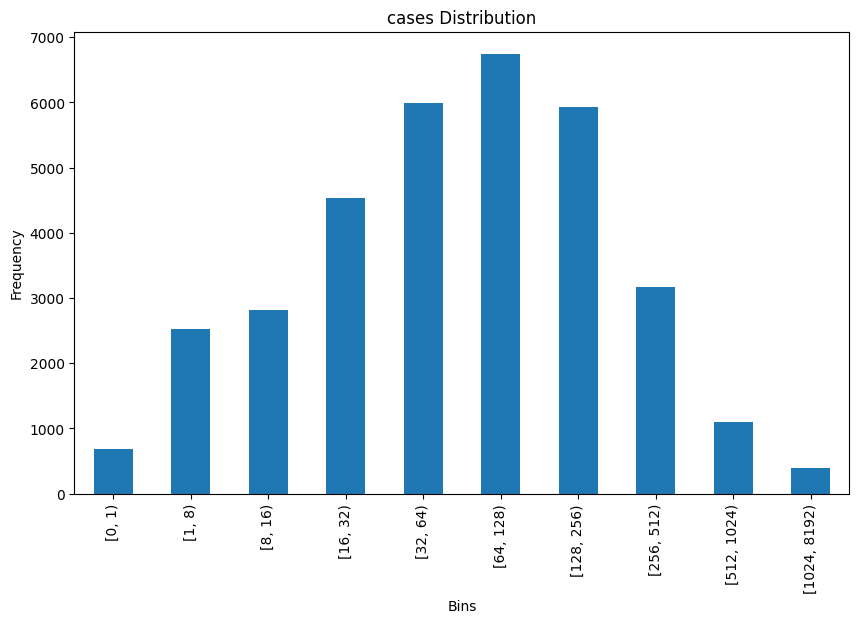

In [11]:
target_col = 'cases'

pd.cut(dataframe[target_col], 
       bins=bin_ranges, 
       right=False, 
       include_lowest=True).value_counts().sort_index().plot(kind='bar', 
                                                             figsize=(10, 6), title=f'{target_col} Distribution', xlabel='Bins', ylabel='Frequency')

In [12]:
risk_classes = list(range(0,10))
risk_classes

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [13]:
bins, bounds = pd.cut(x = dataframe.loc[:, 'cases'], bins=bin_ranges, right=False, include_lowest=True, labels=risk_classes, retbins=True, precision=0)

In [14]:
dataframe['case_bin'] = bins

In [15]:
dataset = dataframe.copy()

In [16]:
dataset['case_bin'] = pd.Categorical(dataset['case_bin'])

In [17]:
# bounds = np.concatenate(([0], bounds))
bounds = np.array(bounds, dtype=int)
print(f'Bounds: {bounds}')

Bounds: [   0    1    8   16   32   64  128  256  512 1024 8192]


In [18]:
dataset.sort_values(["dt_prediction", "location"], inplace=True)
dataset.reset_index(drop=True, inplace=True)

In [19]:
dataset

,location,x,y,dt_prediction,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,...,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,cases,case_bin
0,"(extreme nord, diamare, bogo, balaza)",14.515776,10.786560,2014-10,-0.866,0.5,0.316173,-0.031746,-0.367008,0.031746,...,1377,496,0,144.44,1114,0,97,914,94,5
1,"(extreme nord, diamare, bogo, balda)",14.724237,10.914551,2014-10,-0.866,0.5,0.272376,-0.078135,-0.381671,0.078135,...,1303,489,0,149.02,1078,0,66,1078,7,1
2,"(extreme nord, diamare, bogo, bogo)",14.597860,10.743440,2014-10,-0.866,0.5,0.318198,-0.031092,-0.376078,0.031092,...,1359,489,0,146.88,1124,0,89,891,91,5
3,"(extreme nord, diamare, bogo, borai)",14.606980,10.653607,2014-10,-0.866,0.5,0.315827,-0.054343,-0.400066,0.054343,...,1451,512,0,144.81,1188,0,92,1188,31,3
4,"(extreme nord, diamare, bogo, guinggley)",14.702740,10.792848,2014-10,-0.866,0.5,0.266854,-0.059092,-0.366169,0.059092,...,1343,481,0,145.68,1106,1,93,911,109,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33881,"(extreme nord, mayo-tsanaga, roua, madakonai)",14.023290,10.779370,2024-09,-1.000,0.0,0.557657,0.106765,-0.464755,-0.106765,...,1475,560,0,134.60,1040,1,163,959,155,6
33882,"(extreme nord, mayo-tsanaga, roua, medere)",13.986810,10.689540,2024-09,-1.000,0.0,0.563313,0.120332,-0.467706,-0.120332,...,1490,514,0,127.33,1038,1,173,946,146,6
33883,"(extreme nord, mayo-tsanaga, roua, ndimche)",13.968570,10.827287,2024-09,-1.000,0.0,0.544767,0.119364,-0.448170,-0.119364,...,1468,502,0,129.33,1044,2,175,931,76,5
33884,"(extreme nord, mayo-tsanaga, roua, roua)",13.968570,10.779370,2024-09,-1.000,0.0,0.596169,0.158170,-0.488677,-0.158170,...,1569,569,0,133.83,1146,2,180,801,51,4


In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33886 entries, 0 to 33885
Data columns (total 70 columns):
 #   Column                   Non-Null Count  Dtype    
---  ------                   --------------  -----    
 0   location                 33886 non-null  object   
 1   x                        33886 non-null  float64  
 2   y                        33886 non-null  float64  
 3   dt_prediction            33886 non-null  period[M]
 4   month_sin                33886 non-null  float64  
 5   month_cos                33886 non-null  float64  
 6   ndvi                     33702 non-null  float64  
 7   ndmi                     33702 non-null  float64  
 8   ndwi                     33702 non-null  float64  
 9   ndbi                     33702 non-null  float64  
 10  ndvi_mean                33787 non-null  float64  
 11  ndmi_mean                33787 non-null  float64  
 12  ndwi_mean                33787 non-null  float64  
 13  ndbi_mean                33787 non-null  float

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from Model_Validation_Module import *

In [22]:
X = dataset.select_dtypes(exclude=['object', 'period[M]']).drop(columns=['cases', 'case_bin'])
y = dataset['case_bin']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
# scaler = MinMaxScaler(feature_range = (-1, 1))
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [25]:
imputer = KNNImputer(n_neighbors=3)
imputer.fit(X_train_scaled)
X_train_imputed = pd.DataFrame(imputer.transform(X_train_scaled), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test_scaled), columns=X_test.columns, index=X_test.index)

In [26]:
X_train_imputed = pd.DataFrame(scaler.inverse_transform(X_train_imputed), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(scaler.inverse_transform(X_test_imputed), columns=X_test.columns, index=X_test.index)

In [27]:
X_train_imputed = round_columns(X_train_imputed, round_cols, round_factor)
X_test_imputed = round_columns(X_test_imputed, round_cols, round_factor)

In [28]:
param_grid = {
    'objective': ['reg:squarederror'],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.1, 0.2, 0.3],
    'n_estimators': [100, 150, 200, 250, 300],
    'min_child_weight': [1, 2, 3, 4],
    'gamma': [0, 0.1, 0.2, 0.3]
}

In [29]:
model = xgb.XGBRegressor(random_state=0)

In [30]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # primary scoring
    cv=3,
    verbose=2,
    n_jobs=-1
)

In [31]:
grid_search.fit(X_train_imputed, y_train)

Fitting 3 folds for each of 960 candidates, totalling 2880 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=0, ...),
             n_jobs=-1,
             param_grid={'gamma': [0, 0.1, 0.2, 0.3],
                         'learning_rate': [0.1, 0.2, 0.3],
                         'max_depth': [4, 5, 6, 7],
                         'min_child_weight': [1, 2, 3, 4],
                         'n_estimators': [100, 150, 200, 250, 300],
                         'objective': ['reg:squarederror']},
             scoring='neg_mean_squared_error', verbose=2)

In [32]:
print("Best parameters found:")
print(grid_search.best_params_)
print("Best score (MAE):", -grid_search.best_score_)

Best parameters found:
{'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 300, 'objective': 'reg:squarederror'}
Best score (MAE): 1.0403164818933621


In [ ]:
with open("CM_ExtNord_gridcv_best_params.json", "w") as f:
    json.dump(grid_search.best_params_, f, indent=4)    

In [35]:
best_model = grid_search.best_estimator_

In [36]:
y_train_proba = best_model.predict(X_train_imputed)
y_test_proba = best_model.predict(X_test_imputed)

In [37]:
y_train_pred = np.clip(np.round(y_train_proba), 0, 9).astype(int)
y_test_pred = np.clip(np.round(y_test_proba), 0, 9).astype(int)


In [38]:
results_train = pd.DataFrame({'actual': y_train,'prediction': y_train_pred})
results_test = pd.DataFrame({'actual': y_test,'prediction': y_test_pred})

results_test['dt_prediction'] = dataset.loc[results_test.index, 'dt_prediction']
results_test['dt_temp'] = results_test['dt_prediction']+3

results_train.reset_index(drop=True, inplace=True)
results_test.reset_index(drop=True, inplace=True)

In [39]:
metrics(results_train, results_test, threshold=1)

MAE on train set: 0.3611
MSE on train set: 0.4024
min prediction: 0
max prediction: 9

MAE on test set: 0.7040
MSE on test set: 1.0221
Error <= 1: 89.27 %
min prediction: 0
max prediction: 9


In [40]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    group_by='class',
    metric='mae',
    title='MAE per Risk Class'
)

In [41]:
plot_error_by_group(
    df=results_test,
    y_true_col='actual',
    y_pred_col='prediction',
    group_by='class',
    metric='mse',
    title='MSE per Risk Class'
)

In [42]:
plot_hist_plotly(results_test['actual'].cat.codes, results_test['prediction'])